# 03 — Evaluación del Modelo

Este notebook evalúa el modelo entrenado sobre el conjunto de **test** (imágenes no vistas durante el entrenamiento).

**¿Qué hace?**
1. Carga el mejor modelo guardado (`best.pt`)
2. Corre inferencia sobre el split de test
3. Calcula métricas: mAP50, Precision, Recall por clase
4. Muestra la Confusion Matrix
5. Visualiza ejemplos de predicciones con bounding boxes

**Prerequisito:** Haber completado `02_training.ipynb`

**Glosario rápido para la presentación:**
- **mAP50**: Mean Average Precision con IoU threshold 0.5 — la métrica principal en object detection
- **Precision**: De todas las detecciones que hice, ¿cuántas son correctas?
- **Recall**: De todos los animales reales, ¿cuántos detecté?
- **IoU**: Intersection over Union — qué tan bien se superpone la bbox predicha con la real

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install ultralytics -q

import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
from ultralytics import YOLO

# ─── Rutas — ajustar si corrés en Colab ───────────────────────────────────────
PROJECT_ROOT  = "/content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector"
DATA_YAML     = f"{PROJECT_ROOT}/data/data.yaml"
BEST_MODEL = f"{PROJECT_ROOT}/outputs/yolov8n_gtm_v1/weights/best.pt"
RESULTS_DIR   = f"{PROJECT_ROOT}/outputs/evaluation"
TEST_IMG_DIR  = f"{PROJECT_ROOT}/data/dataset/test/images"

os.makedirs(RESULTS_DIR, exist_ok=True)
print("✅ Setup listo")
print(f"   Modelo: {BEST_MODEL}")

✅ Setup listo
   Modelo: /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/outputs/yolov8n_gtm_v1/weights/best.pt


## 1. Cargar modelo

In [ ]:
model = YOLO(BEST_MODEL)
class_names = model.names  # diccionario {0: 'Pavon', 1: 'Guatusa', ...}
print(f"✅ Modelo cargado")
print(f"   Clases ({len(class_names)}):")
for idx, name in class_names.items():
    print(f"     {idx:2d}: {name}")

✅ Modelo cargado
   Clases (12):
      0: Pavon
      1: Guatusa
      2: Ocelote
      3: Cabro de monte
      4: Pavo ocelado
      5: Pizote
      6: Venado
      7: Jaguar
      8: Saino
      9: Puma
     10: Danta
     11: Chancho de monte


## 2. Evaluación sobre el split de test

Ultralytics calcula todas las métricas estándar de COCO automáticamente.

In [ ]:
print("Corriendo evaluación sobre el split de test...")
metrics = model.val(
    data    = DATA_YAML,
    split   = "test",
    imgsz   = 640,
    batch   = 16,
    plots   = True,
    save_json = False,
    project = RESULTS_DIR,
    name    = "test_eval",
    exist_ok= True,
)
print("\n✅ Evaluación completada")

Corriendo evaluación sobre el split de test...
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 0.3±0.2 MB/s, size: 351.1 KB)
val: Scanning /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/data/dataset/test/labels... 357 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 357/357 2.7it/s 2:13
val: New cache created: /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/data/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.7it/s 8.5s
                   all        357        492      0.864      0.802      0.855      0.679
                 Pavon         37         50      0.786       0.66      0.824      0.608
               Guatusa         30         32      0.905      0.891      0.922      0.706


## 3. Resumen de métricas

In [ ]:
print("=" * 55)
print("MÉTRICAS GLOBALES — SPLIT DE TEST")
print("=" * 55)
print(f"  mAP50     : {metrics.box.map50:.4f}  ({metrics.box.map50*100:.1f}%)")
print(f"  mAP50-95  : {metrics.box.map:.4f}  ({metrics.box.map*100:.1f}%)")
print(f"  Precision : {metrics.box.mp:.4f}  ({metrics.box.mp*100:.1f}%)")
print(f"  Recall    : {metrics.box.mr:.4f}  ({metrics.box.mr*100:.1f}%)")

print("\n" + "=" * 55)
print("MÉTRICAS POR CLASE")
print("=" * 55)
print(f"  {'Clase':<22} {'AP50':>8} {'Precision':>10} {'Recall':>8}")
print("  " + "-" * 50)
for i, name in class_names.items():
    if i < len(metrics.box.ap50):
        ap50 = metrics.box.ap50[i]
        p    = metrics.box.p[i] if i < len(metrics.box.p) else float('nan')
        r    = metrics.box.r[i] if i < len(metrics.box.r) else float('nan')
        print(f"  {name:<22} {ap50:>7.3f}  {p:>9.3f}  {r:>7.3f}")

MÉTRICAS GLOBALES — SPLIT DE TEST
  mAP50     : 0.8550  (85.5%)
  mAP50-95  : 0.6789  (67.9%)
  Precision : 0.8639  (86.4%)
  Recall    : 0.8018  (80.2%)

MÉTRICAS POR CLASE
  Clase                      AP50  Precision   Recall
  --------------------------------------------------
  Pavon                    0.824      0.786    0.660
  Guatusa                  0.922      0.905    0.891
  Ocelote                  0.787      0.748    0.849
  Cabro de monte           0.888      0.856    0.867
  Pavo ocelado             0.849      0.898    0.747
  Pizote                   0.779      0.891    0.727
  Venado                   0.886      0.887    0.821
  Jaguar                   0.841      0.909    0.781
  Saino                    0.846      0.805    0.800
  Puma                     0.921      0.926    0.860
  Danta                    0.843      0.901    0.833
  Chancho de monte         0.872      0.854    0.785


## 4. Visualizar imágenes generadas por Ultralytics


📊 Confusion Matrix (normalizada)


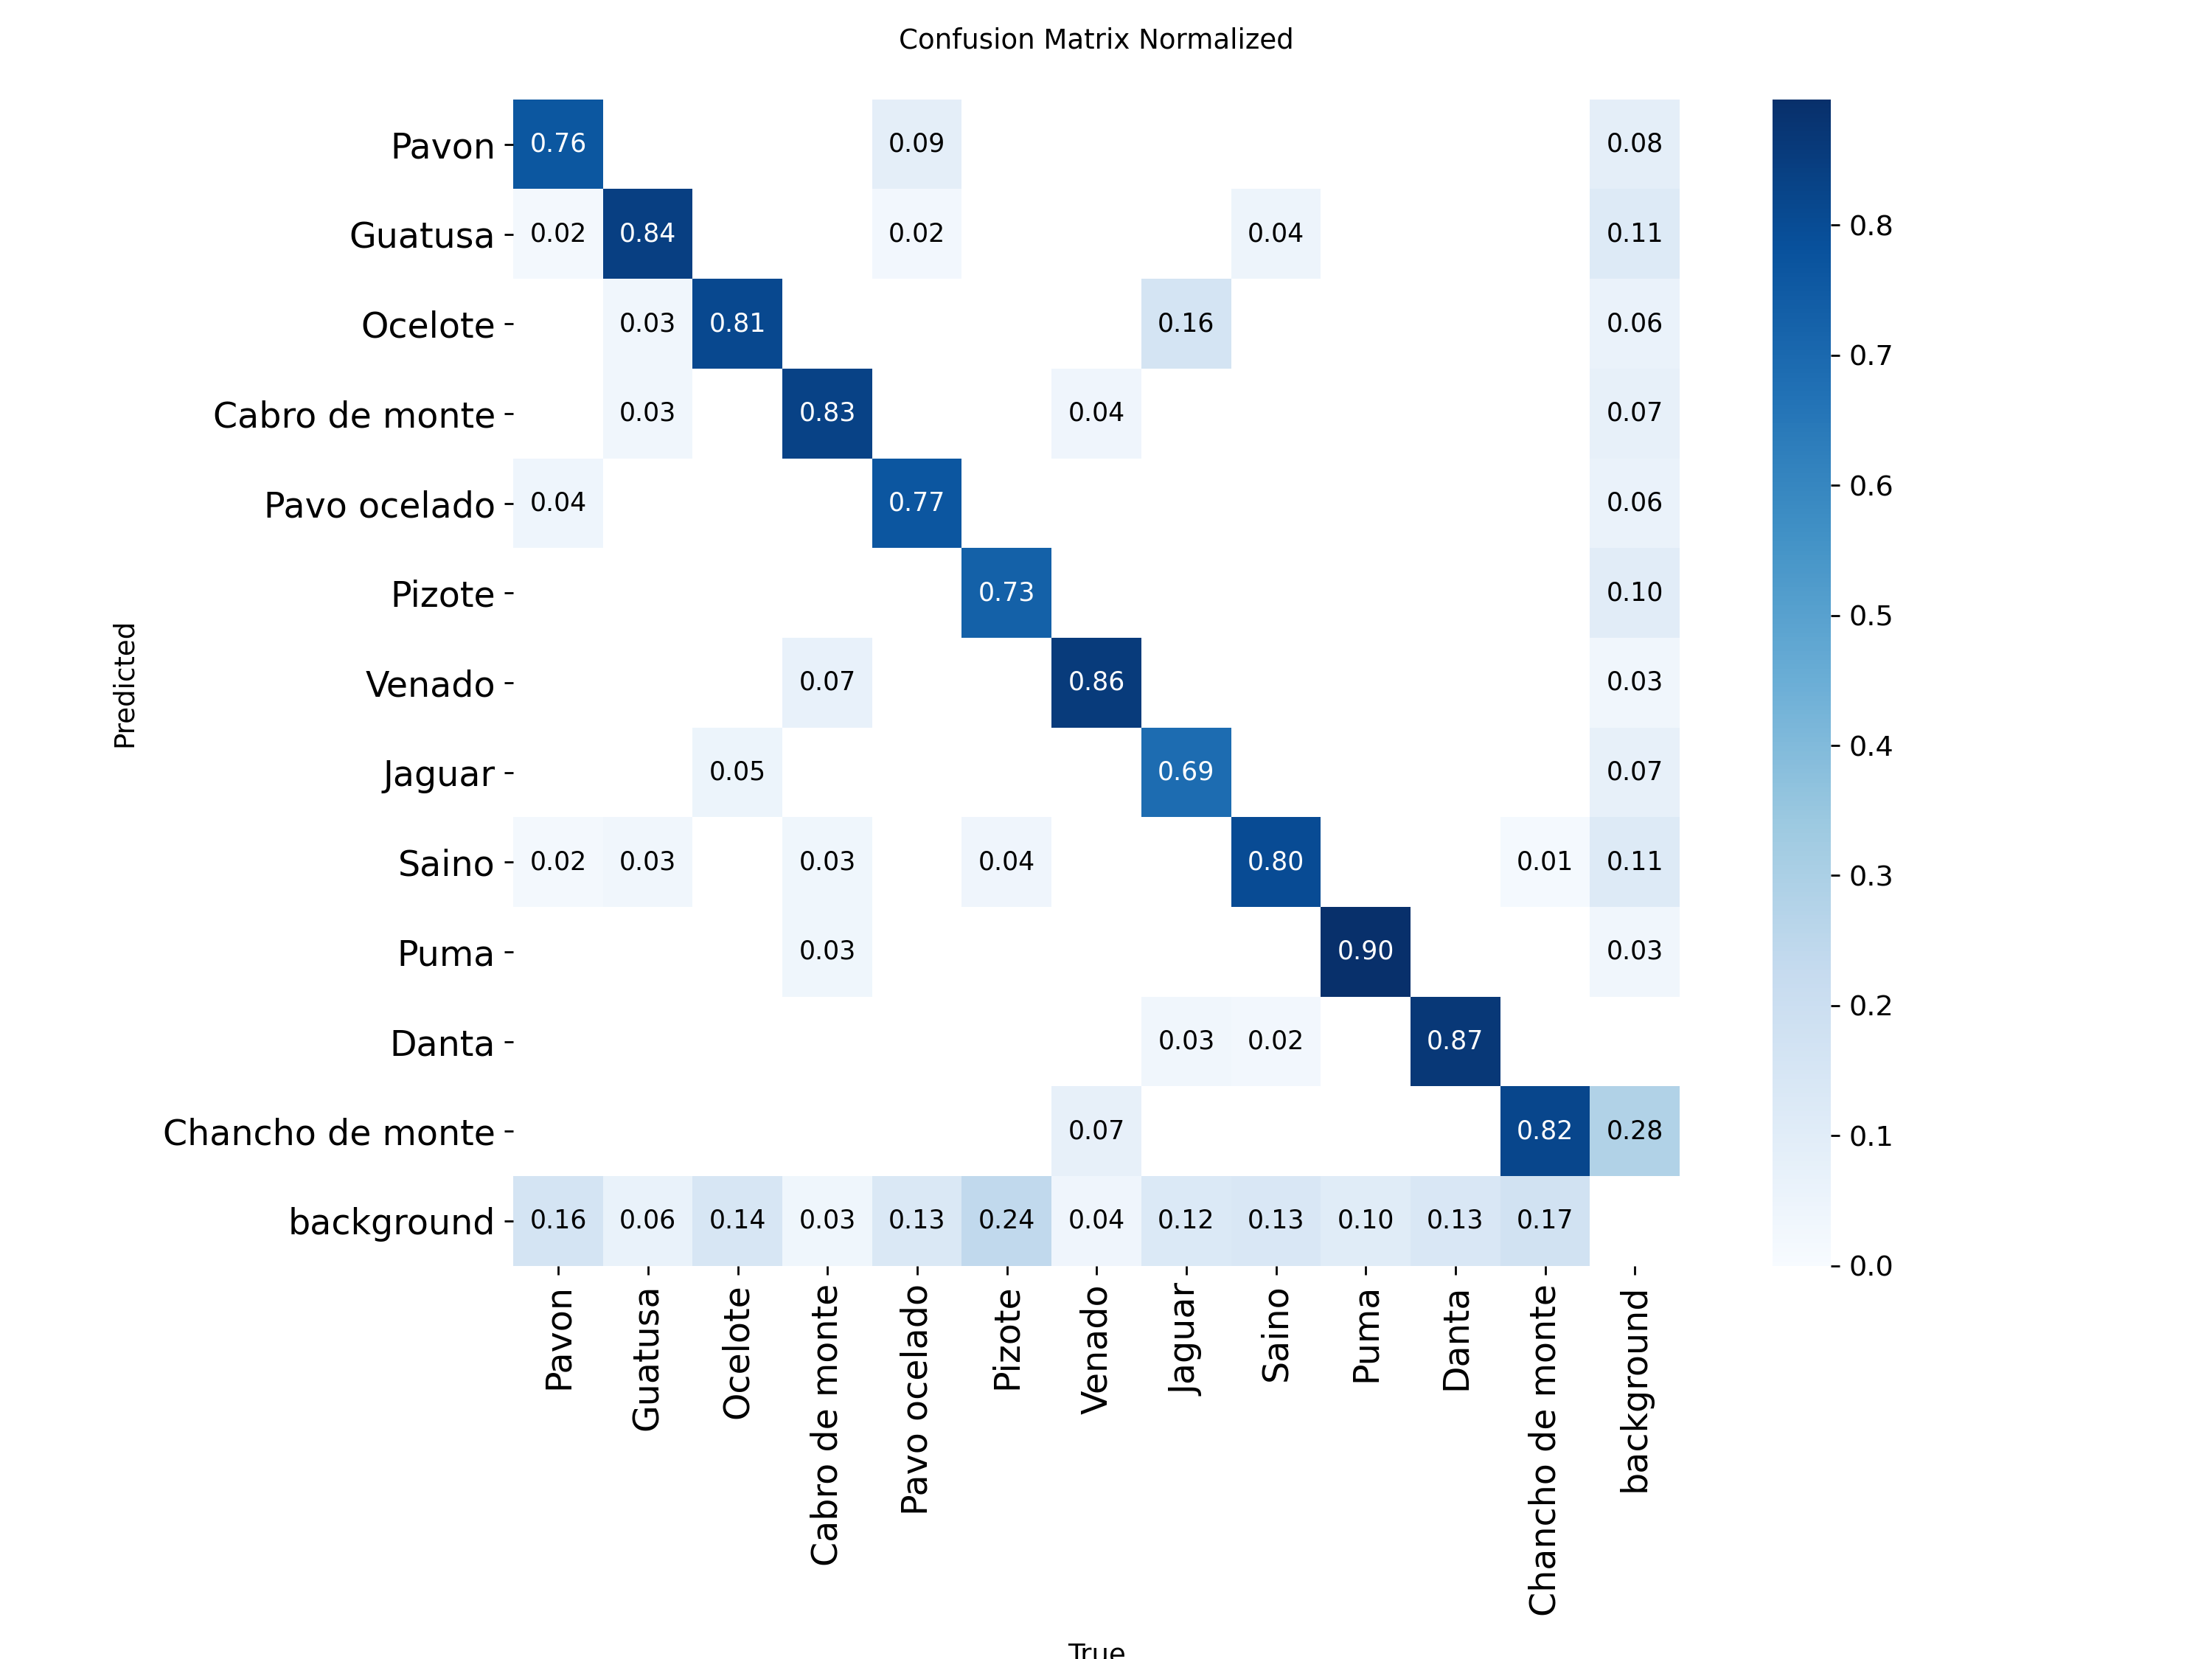

  (No encontrado: /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/outputs/evaluation/test_eval/PR_curve.png)
  (No encontrado: /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/outputs/evaluation/test_eval/P_curve.png)
  (No encontrado: /content/drive/MyDrive/Wildlife Camera Trap Detector/wildlife-detector/outputs/evaluation/test_eval/R_curve.png)


In [ ]:
from IPython.display import Image as IPyImage, display

eval_dir = Path(RESULTS_DIR) / "test_eval"

# Mostrar confusion matrix y curvas P-R
plots_to_show = [
    ("confusion_matrix_normalized.png", "Confusion Matrix (normalizada)"),
    ("PR_curve.png",                    "Curva Precision-Recall"),
    ("P_curve.png",                     "Curva de Precision"),
    ("R_curve.png",                     "Curva de Recall"),
]

for filename, title in plots_to_show:
    path = eval_dir / filename
    if path.exists():
        print(f"\n📊 {title}")
        display(IPyImage(str(path), width=700))
    else:
        print(f"  (No encontrado: {path})")

## 5. Visualizar predicciones en imágenes de test

In [ ]:
# Colores por clase para las bounding boxes
COLORS = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabed4",
    "#469990", "#dcbeff",
]

def visualize_predictions(img_path, predictions, class_names, conf_threshold=0.25):
    """Dibuja bounding boxes con etiqueta y confianza sobre una imagen."""
    img = np.array(Image.open(img_path).convert("RGB"))
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.imshow(img)
    ax.set_title(Path(img_path).name, fontsize=10)
    ax.axis("off")

    boxes = predictions.boxes
    if boxes is None or len(boxes) == 0:
        ax.set_title(f"{Path(img_path).name} — sin detecciones", fontsize=10)
        return fig

    for box in boxes:
        conf = float(box.conf[0])
        if conf < conf_threshold:
            continue
        cls_id = int(box.cls[0])
        name   = class_names.get(cls_id, str(cls_id))
        color  = COLORS[cls_id % len(COLORS)]

        # Coordenadas absolutas
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        bw, bh = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1), bw, bh,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 4,
            f"{name} {conf:.0%}",
            fontsize=9, color="white",
            bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor="none")
        )
    return fig

print("✅ Función de visualización lista")

✅ Función de visualización lista


In [ ]:
# Seleccionar 12 imágenes de test al azar y mostrar predicciones
test_images = list(Path(TEST_IMG_DIR).glob("*.jpg"))
sample_imgs = random.sample(test_images, min(12, len(test_images)))

print(f"Mostrando predicciones sobre {len(sample_imgs)} imágenes de test...")

results = model.predict(
    source    = [str(p) for p in sample_imgs],
    imgsz     = 640,
    conf      = 0.25,   # umbral de confianza
    iou       = 0.45,   # umbral de NMS
    verbose   = False,
)

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, (img_path, pred) in enumerate(zip(sample_imgs, results)):
    img = np.array(Image.open(img_path).convert("RGB"))
    axes[i].imshow(img)
    axes[i].axis("off")

    boxes = pred.boxes
    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            conf   = float(box.conf[0])
            cls_id = int(box.cls[0])
            name   = class_names.get(cls_id, str(cls_id))
            color  = COLORS[cls_id % len(COLORS)]
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            axes[i].add_patch(rect)
            axes[i].text(
                x1, y1 - 4, f"{name} {conf:.0%}",
                fontsize=7, color="white",
                bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor="none")
            )
    else:
        axes[i].set_title("sin detecciones", fontsize=8)

plt.suptitle("Predicciones sobre imágenes de test", fontsize=14, y=1.01)
plt.tight_layout()

out_path = Path(RESULTS_DIR) / "sample_predictions.png"
plt.savefig(out_path, bbox_inches="tight", dpi=120)
plt.show()
print(f"✅ Guardado en {out_path}")

Output hidden; open in https://colab.research.google.com to view.

## 6. Análisis de errores — Falsos positivos y falsos negativos

In [ ]:
# Contar detecciones por clase sobre todo el test set
all_test_imgs = list(Path(TEST_IMG_DIR).glob("*.jpg"))
print(f"Total imágenes de test: {len(all_test_imgs)}")
print("Corriendo inferencia sobre todo el test set...")

all_results = model.predict(
    source  = [str(p) for p in all_test_imgs],
    imgsz   = 640,
    conf    = 0.25,
    verbose = False,
    stream  = True,
)

det_counts = {name: 0 for name in class_names.values()}
imgs_with_detections = 0
imgs_without = 0

for r in all_results:
    if r.boxes is not None and len(r.boxes) > 0:
        imgs_with_detections += 1
        for box in r.boxes:
            name = class_names.get(int(box.cls[0]), "unknown")
            det_counts[name] += 1
    else:
        imgs_without += 1

print(f"\nImágenes con detecciones  : {imgs_with_detections}")
print(f"Imágenes sin detecciones  : {imgs_without}")
print("\nDetecciones por clase:")
for name, cnt in sorted(det_counts.items(), key=lambda x: -x[1]):
    bar = "█" * (cnt // 5)
    print(f"  {name:<22} {cnt:4d}  {bar}")

Total imágenes de test: 357
Corriendo inferencia sobre todo el test set...

Imágenes con detecciones  : 334
Imágenes sin detecciones  : 23

Detecciones por clase:
  Chancho de monte         97  ███████████████████
  Pavon                    47  █████████
  Saino                    45  █████████
  Pizote                   44  ████████
  Pavo ocelado             42  ████████
  Guatusa                  36  ███████
  Danta                    32  ██████
  Puma                     29  █████
  Ocelote                  27  █████
  Cabro de monte           27  █████
  Venado                   27  █████
  Jaguar                   27  █████


## 7. Conclusiones

Completá esta sección con los resultados reales después de correr el entrenamiento.

In [ ]:
print("RESUMEN PARA LA PRESENTACIÓN")
print("=" * 55)
print(f"  Modelo     : YOLOv8n (nano) — transfer learning desde COCO")
print(f"  Dataset    : WCS Camera Traps — Guatemala (12 especies)")
print(f"  Imágenes   : ~3,600 (train/val/test: 70/20/10)")
print(f"  mAP50 test : {metrics.box.map50:.3f}")
print()
print("  Fortalezas del modelo:")
best_class = max(class_names.values(),
    key=lambda n: metrics.box.ap50[list(class_names.values()).index(n)]
    if list(class_names.values()).index(n) < len(metrics.box.ap50) else 0
)
print(f"    Mejor clase: {best_class}")
print()
print("  Limitaciones:")
print("    - Dataset relativamente pequeño (~300 imgs/clase)")
print("    - Solo 12 de 228 especies posibles")
print("    - Imágenes de Guatemala, no exactamente de Costa Rica")
print()
print("✅ Siguiente paso → 04_video_inference.ipynb")

RESUMEN PARA LA PRESENTACIÓN
  Modelo     : YOLOv8n (nano) — transfer learning desde COCO
  Dataset    : WCS Camera Traps — Guatemala (12 especies)
  Imágenes   : ~3,600 (train/val/test: 70/20/10)
  mAP50 test : 0.855

  Fortalezas del modelo:
    Mejor clase: Guatusa

  Limitaciones:
    - Dataset relativamente pequeño (~300 imgs/clase)
    - Solo 12 de 228 especies posibles
    - Imágenes de Guatemala, no exactamente de Costa Rica

✅ Siguiente paso → 04_video_inference.ipynb


In [1]:
plots_to_show = [
    ("confusion_matrix_normalized.png", "Confusion Matrix (normalizada)"),
    ("BoxPR_curve.png",                 "Curva Precision-Recall"),
    ("BoxP_curve.png",                  "Curva de Precision"),
    ("BoxR_curve.png",                  "Curva de Recall"),
    ("BoxF1_curve.png",                 "Curva F1"),
]

for filename, title in plots_to_show:
    path = eval_dir / filename
    if path.exists():
        print(f"\n📊 {title}")
        display(IPyImage(str(path), width=700))
    else:
        print(f"  (No encontrado: {path})")

NameError: name 'eval_dir' is not defined